NOTEBOOK 4: DEPLOYMENT & PREDICTIONS

[STEP 1] Loading trained model...
✓ Loaded Random Forest model
✓ Loaded feature scaler

[STEP 2] Loading feature information...
✓ Loaded 50 feature names

[STEP 3] Loading data for predictions...
✓ Loaded 5209 records
✓ Latest timestamp: 2026-01-04 22:00:00
✓ Current price: €89.21/MWh

[STEP 4] Creating prediction function...
✓ Prediction function created

24-HOUR PRICE FORECAST (Using Random Forest Model)

Current status:
  Timestamp: 2026-01-04 22:00:00
  Current price: €89.21/MWh

Hour   Predicted Price      Change          % Change    
----------------------------------------------------------------------
+1    €68.27              ↓ €20.94           -23.5%
+2    €80.13              ↓ €9.08            -10.2%
+3    €80.08              ↓ €9.13            -10.2%
+4    €80.08              ↓ €9.13            -10.2%
+5    €80.44              ↓ €8.77             -9.8%
+6    €80.41              ↓ €8.80             -9.9%
+7    €79.70              ↓ €9.51

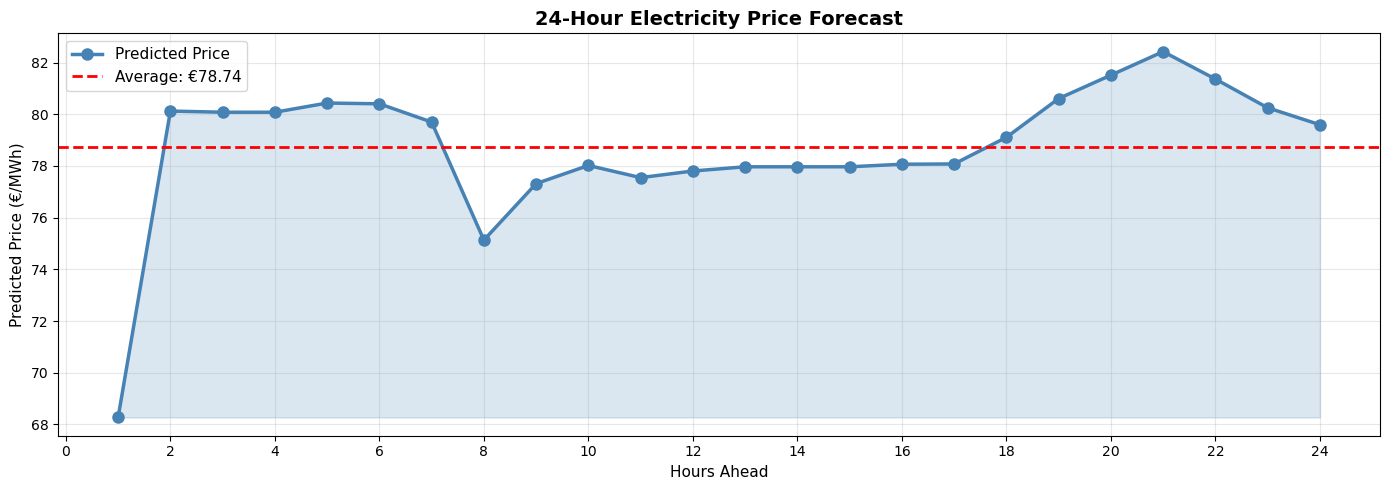

✓ Saved: plots/08_24hour_forecast.png

DEPLOYMENT COMPLETE!

✓ Model Deployed: Random Forest

✓ Predictions Generated:
  • 24-hour forecast created
  • Plot saved to plots/08_24hour_forecast.png

✓ To use predictions:
  • Call: result = make_prediction(df, hours_ahead=1)
  • Access: result['predicted_price'], result['change']


In [2]:
# NOTEBOOK 4: DEPLOYMENT & PREDICTIONS

import os
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("="*70)
print("NOTEBOOK 4: DEPLOYMENT & PREDICTIONS")
print("="*70)

# ===== LOAD MODEL AND SCALER =====
print("\n[STEP 1] Loading trained model...")

try:
    try:
        with open('models/xgboost.pkl', 'rb') as f:
            model = pickle.load(f)
        model_name = 'XGBoost'
        print(f"✓ Loaded XGBoost model")
    except FileNotFoundError:
        with open('models/random_forest.pkl', 'rb') as f:
            model = pickle.load(f)
        model_name = 'Random Forest'
        print(f"✓ Loaded Random Forest model")
    
    with open('models/scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    print(f"✓ Loaded feature scaler")
    
except FileNotFoundError as e:
    print(f"✗ Error: {e}")
    print(f"  Make sure to run Notebook 3 first!")
    exit()

# ===== LOAD FEATURE NAMES =====
print("\n[STEP 2] Loading feature information...")

with open('data/feature_names.txt', 'r') as f:
    feature_names = [line.strip() for line in f.readlines()]
print(f"✓ Loaded {len(feature_names)} feature names")

# ===== LOAD DATA =====
print("\n[STEP 3] Loading data for predictions...")

df = pd.read_csv('data/electricity_prices_clean.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f"✓ Loaded {len(df)} records")
print(f"✓ Latest timestamp: {df['timestamp'].max()}")
print(f"✓ Current price: €{df['price'].iloc[-1]:.2f}/MWh")

# ===== PREDICTION FUNCTION =====
print("\n[STEP 4] Creating prediction function...")

def make_prediction(df_input, hours_ahead=1):
    """
    Predict electricity price for N hours ahead
    
    Args:
        df_input: DataFrame with 'timestamp' and 'price' columns
        hours_ahead: Hours to predict ahead (1-24 recommended)
    
    Returns:
        dict with prediction details
    """
    
    try:
        last_row = df_input.iloc[-1].copy()
        last_price = last_row['price']
        last_timestamp = last_row['timestamp']
        
        next_timestamp = last_timestamp + pd.Timedelta(hours=hours_ahead)
        hour = next_timestamp.hour
        month = next_timestamp.month
        day_of_week = next_timestamp.dayofweek
        
        # Get historical values for features
        prices_last_24 = df_input['price'].tail(24).values
        prices_last_48 = df_input['price'].tail(48).values
        
        # Create feature dictionary
        features = {
            'hour': hour,
            'day_of_week': day_of_week,
            'month': month,
            'is_weekend': 1 if day_of_week >= 5 else 0,
            'is_night': 1 if (hour >= 22 or hour <= 6) else 0,
            'hour_sin': np.sin(2 * np.pi * hour / 24),
            'hour_cos': np.cos(2 * np.pi * hour / 24),
            'month_sin': np.sin(2 * np.pi * month / 12),
            'month_cos': np.cos(2 * np.pi * month / 12),
            'quarter': (month - 1) // 3 + 1,
            'day_of_month': next_timestamp.day,
            'price_lag_1': last_price,
            'price_lag_2': df_input.iloc[-2]['price'] if len(df_input) >= 2 else last_price,
            'price_lag_3': df_input.iloc[-3]['price'] if len(df_input) >= 3 else last_price,
            'price_lag_6': df_input.iloc[-6]['price'] if len(df_input) >= 6 else last_price,
            'price_lag_12': df_input.iloc[-12]['price'] if len(df_input) >= 12 else last_price,
            'price_lag_24': df_input.iloc[-24]['price'] if len(df_input) >= 24 else last_price,
            'price_lag_48': df_input.iloc[-48]['price'] if len(df_input) >= 48 else last_price,
            'price_lag_72': df_input.iloc[-72]['price'] if len(df_input) >= 72 else last_price,
            'price_lag_168': df_input.iloc[-168]['price'] if len(df_input) >= 168 else last_price,
            'price_rolling_mean_6': prices_last_24[-6:].mean() if len(prices_last_24) >= 6 else last_price,
            'price_rolling_mean_12': prices_last_24[-12:].mean() if len(prices_last_24) >= 12 else last_price,
            'price_rolling_mean_24': prices_last_24.mean(),
            'price_rolling_mean_48': prices_last_48.mean() if len(prices_last_48) >= 48 else last_price,
            'price_rolling_std_6': prices_last_24[-6:].std() if len(prices_last_24) >= 6 else 0,
            'price_rolling_std_12': prices_last_24[-12:].std() if len(prices_last_24) >= 12 else 0,
            'price_rolling_std_24': prices_last_24.std(),
            'price_rolling_std_48': prices_last_48.std() if len(prices_last_48) >= 48 else 0,
            'price_rolling_min_6': prices_last_24[-6:].min() if len(prices_last_24) >= 6 else last_price,
            'price_rolling_min_12': prices_last_24[-12:].min() if len(prices_last_24) >= 12 else last_price,
            'price_rolling_min_24': prices_last_24.min(),
            'price_rolling_min_48': prices_last_48.min() if len(prices_last_48) >= 48 else last_price,
            'price_rolling_max_6': prices_last_24[-6:].max() if len(prices_last_24) >= 6 else last_price,
            'price_rolling_max_12': prices_last_24[-12:].max() if len(prices_last_24) >= 12 else last_price,
            'price_rolling_max_24': prices_last_24.max(),
            'price_rolling_max_48': prices_last_48.max() if len(prices_last_48) >= 48 else last_price,
            'price_rolling_median_6': np.median(prices_last_24[-6:]) if len(prices_last_24) >= 6 else last_price,
            'price_rolling_median_12': np.median(prices_last_24[-12:]) if len(prices_last_24) >= 12 else last_price,
            'price_rolling_median_24': np.median(prices_last_24),
            'price_rolling_median_48': np.median(prices_last_48) if len(prices_last_48) >= 48 else last_price,
            'price_change_1h': df_input.iloc[-1]['price'] - df_input.iloc[-2]['price'] if len(df_input) >= 2 else 0,
            'price_change_6h': df_input.iloc[-1]['price'] - df_input.iloc[-6]['price'] if len(df_input) >= 6 else 0,
            'price_change_24h': df_input.iloc[-1]['price'] - df_input.iloc[-24]['price'] if len(df_input) >= 24 else 0,
            'price_pct_change_24h': ((df_input.iloc[-1]['price'] - df_input.iloc[-24]['price']) / df_input.iloc[-24]['price'] * 100) if len(df_input) >= 24 else 0,
            'price_range_12': prices_last_24[-12:].max() - prices_last_24[-12:].min() if len(prices_last_24) >= 12 else 0,
            'price_range_24': prices_last_24.max() - prices_last_24.min(),
            'price_range_48': prices_last_48.max() - prices_last_48.min() if len(prices_last_48) >= 48 else 0,
            'volatility_12': prices_last_24[-12:].std() if len(prices_last_24) >= 12 else 0,
            'volatility_24': prices_last_24.std(),
            'volatility_48': prices_last_48.std() if len(prices_last_48) >= 48 else 0,
        }
        
        # Create DataFrame
        X_new = pd.DataFrame([features])
        
        # Add any missing features
        for fname in feature_names:
            if fname not in X_new.columns:
                X_new[fname] = 0
        
        # Keep only required features in correct order
        X_new = X_new[feature_names]
        
        # Predict
        prediction = model.predict(X_new)[0]
        prediction = max(0, prediction)  # Ensure non-negative
        
        return {
            'hours_ahead': hours_ahead,
            'timestamp': next_timestamp,
            'predicted_price': prediction,
            'current_price': last_price,
            'change': prediction - last_price,
            'pct_change': ((prediction - last_price) / last_price * 100) if last_price > 0 else 0
        }
    
    except Exception as e:
        print(f"✗ Error: {e}")
        return None

print(f"✓ Prediction function created")

# ===== TEST PREDICTIONS =====
print("\n" + "="*70)
print(f"24-HOUR PRICE FORECAST (Using {model_name} Model)")
print("="*70)

print(f"\nCurrent status:")
print(f"  Timestamp: {df['timestamp'].max()}")
print(f"  Current price: €{df['price'].iloc[-1]:.2f}/MWh")

print(f"\n{'Hour':<6} {'Predicted Price':<20} {'Change':<15} {'% Change':<12}")
print(f"{'-'*70}")

predictions_list = []
for hour in range(1, 25):
    result = make_prediction(df, hours_ahead=hour)
    if result:
        predictions_list.append(result)
        change = result['change']
        pct_change = result['pct_change']
        change_symbol = '↑' if change > 0 else '↓' if change < 0 else '→'
        
        print(f"+{hour:<4} €{result['predicted_price']:<18.2f} {change_symbol} €{abs(change):<13.2f} {pct_change:>+7.1f}%")

# ===== FORECAST VISUALIZATION =====
print(f"\n[PLOT] Creating 24-hour forecast plot...")

if predictions_list:
    hours = list(range(1, len(predictions_list) + 1))
    prices = [p['predicted_price'] for p in predictions_list]
    
    plt.figure(figsize=(14, 5))
    plt.plot(hours, prices, marker='o', linewidth=2.5, markersize=8, color='steelblue', label='Predicted Price')
    plt.axhline(y=np.mean(prices), color='red', linestyle='--', linewidth=2, label=f'Average: €{np.mean(prices):.2f}')
    plt.fill_between(hours, min(prices), prices, alpha=0.2, color='steelblue')
    
    plt.title('24-Hour Electricity Price Forecast', fontsize=14, fontweight='bold')
    plt.xlabel('Hours Ahead', fontsize=11)
    plt.ylabel('Predicted Price (€/MWh)', fontsize=11)
    plt.xticks(range(0, 25, 2))
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.savefig('plots/08_24hour_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: plots/08_24hour_forecast.png")

# ===== FINAL SUMMARY =====
print("\n" + "="*70)
print("DEPLOYMENT COMPLETE!")
print("="*70)

print(f"\n✓ Model Deployed: {model_name}")
print(f"\n✓ Predictions Generated:")
print(f"  • 24-hour forecast created")
print(f"  • Plot saved to plots/08_24hour_forecast.png")

print(f"\n✓ To use predictions:")
print(f"  • Call: result = make_prediction(df, hours_ahead=1)")
print(f"  • Access: result['predicted_price'], result['change']")



